In [1]:
from datascience import *
import numpy as np
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [2]:
ckd = Table.read_table('ckd.csv')
ckd = ckd.relabeled('Blood Glucose Random', 'Glucose').select('Glucose', 'Hemoglobin', 'White Blood Cell Count', 'Class')

In [3]:
patients = Table.read_table('breast-cancer.csv').drop('ID')

def randomize_column(a):
    return a + np.random.normal(0.0, 0.09, size=len(a))

jittered = Table().with_columns([
        'Bland Chromatin (jittered)', 
        randomize_column(patients.column('Bland Chromatin')),
        'Single Epithelial Cell Size (jittered)', 
        randomize_column(patients.column('Single Epithelial Cell Size')),
        'Class',
        patients.column('Class')
    ])

# Google Science Fair

Brittany Wenger, a 17-year-old high school student in 2012
 won by building a breast cancer classifier with 99% accuracy. 
 
After imaging, technicians went thru the images and measured certain attributes that helped determine whether the patient had breast cancer. 

* Class of 0: Does not have cancer </br>
* Class of 1: Does have cancer

Import the table and describe: 

In [4]:
# Import the patient data used to determine they had breast cancer. 

patients = Table.read_table('breast-cancer.csv').drop('ID')
patients.show(5)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
5,1,1,1,2,1,3,1,1,0
5,4,4,5,7,10,3,2,1,0
3,1,1,1,2,2,3,1,1,0
6,8,8,1,3,4,3,7,1,0
4,1,1,3,2,1,3,1,1,0


In [5]:
# COMPLETE: Generate a small table that shows have many patients have cancer and how many do not.
# Do not reassign. 

patients.group('Class')

Class,count
0,444
1,239


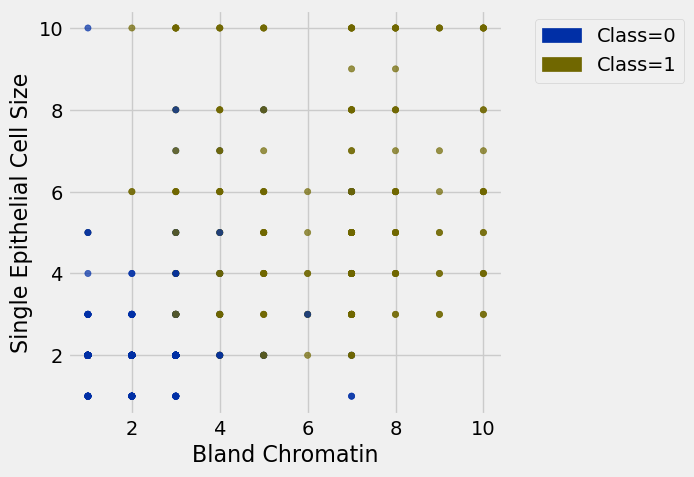

In [6]:
# COMPLETE: Generate a scatter comparing the Bland Chromatin and Single Epithelial Cell Size grouped by Class.

patients.scatter('Bland Chromatin', 'Single Epithelial Cell Size', group='Class')

***QUESTION: Does our graph look like it represents all 680+ patients?***



***QUESTION: Why do you think that is?***


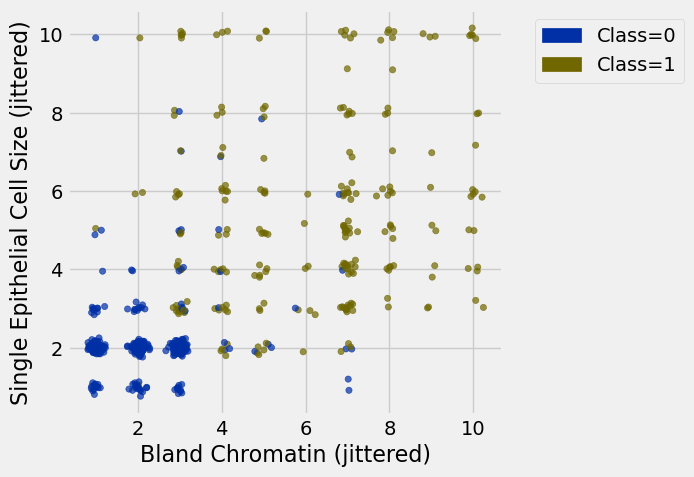

In [7]:
# Add 'noise' to the data points to reveal hidden values. 

jittered.scatter(0, 1, group='Class')

## Distance ##
Use the distance formula from Pythagoras to determine the distance between two points. 


In [8]:
# COMPLETE: Create a function that will return the distance between two points, represented as arrays.

def distance(pt1, pt2):
    """Return the distance between two points, represented as arrays"""
    return np.sqrt(sum(pt1 - pt2) ** 2)

In [9]:
# Creates a function that uses the above function to return the distance between two numerical rows of a table.

def row_distance(row1, row2):
    """Return the distance between two numerical rows of a table"""
    return distance( np.array(row1), np.array(row2) )

In [10]:
# COMPLETE: Create a new table of patients that does not show the Class.

attributes = patients.drop('Class')
attributes.show(3)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
5,1,1,1,2,1,3,1,1
5,4,4,5,7,10,3,2,1
3,1,1,1,2,2,3,1,1


In [11]:
# COMPLETE: Compare the distance for Row 2 with Row 2. What should we get?

row_distance( attributes.row(2), attributes.row(2) )

0.0

In [12]:
# COMPLETE: Compare the distance for Row 0 with Row 1

row_distance( attributes.row(0), attributes.row(1) )

25.0

In [13]:
# COMPLETE: Compare the distance for Row 0 with Row 2

row_distance( attributes.row(0), attributes.row(2) )

1.0

# The Classifier

Use the distancance formula to classify an incoming patient based on its closeness to other similar points. 

You can specify how many points to consider as neighbors. We are calling that value $k$.

The assigned class will be based on the classification of the majority of the $k$ neighbors. 

We can test our classifer by taking a known record and running it through to see if it is correctly classified. 

In [14]:
def distances(training, example):
    """
    Compute distance between example and every row in training.
    Return training augmented with Distance column
    """
    distances = make_array()
    attributes_only = training.drop('Class')
    
    for row in attributes_only.rows:
        distances = np.append(distances, row_distance(row, example))
    
#   ^ SAME AS DOING:
#
#   for i in np.arange(attributes_only.num_rows):
#       row = attributes_only.row(i)
#       distances = np.append(distances, row_distance(row, example))
        
    return training.with_column('Distance_to_ex', distances)

In [15]:
# Let Row 21 be our example patient to make sure the classifier is working. 

example = patients.row(21)
example

Row(Clump Thickness=10, Uniformity of Cell Size=5, Uniformity of Cell Shape=5, Marginal Adhesion=3, Single Epithelial Cell Size=6, Bare Nuclei=7, Bland Chromatin=7, Normal Nucleoli=10, Mitoses=1, Class=1)

In [16]:
# COMPLETE: Reassign example to the row 21 so the class is not included in the information.

example = attributes.row(21)
example

Row(Clump Thickness=10, Uniformity of Cell Size=5, Uniformity of Cell Shape=5, Marginal Adhesion=3, Single Epithelial Cell Size=6, Bare Nuclei=7, Bland Chromatin=7, Normal Nucleoli=10, Mitoses=1)

In [17]:
# Measure the distances, importing the table excluding row 21.

distances(patients.exclude(21), example).sort('Distance_to_ex')

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class,Distance_to_ex
10,7,7,3,8,5,7,4,3,1,0
8,9,9,5,3,5,7,7,1,1,0
7,9,4,10,10,3,5,3,3,1,0
9,10,10,1,10,8,3,3,1,1,1
3,6,6,6,5,10,6,8,3,1,1
7,5,3,7,4,10,7,5,5,1,1
5,10,10,3,8,1,5,10,3,1,1
10,10,9,3,7,5,3,5,1,1,1
9,10,10,1,10,8,3,3,1,1,1
10,5,8,10,3,10,5,1,3,1,1


In [18]:
# What does this function do?

def closest(training, example, k):
    """
    Return a table of the k closest neighbors to example
    """
    return distances(training, example).sort('Distance_to_ex').take(np.arange(k))

In [19]:
# COMPLETE: Run the function with 5 neighbors. 

closest(patients.exclude(21), example, 5)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class,Distance_to_ex
10,7,7,3,8,5,7,4,3,1,0
8,9,9,5,3,5,7,7,1,1,0
7,9,4,10,10,3,5,3,3,1,0
9,10,10,1,10,8,3,3,1,1,1
3,6,6,6,5,10,6,8,3,1,1


In [20]:
closest(patients.exclude(21), example, 5).group('Class').sort('count', descending=True)

Class,count
1,5


***QUESTION: Based on the nearest neighbors, what would patient 21 be classified as? Is that correct?***

In [21]:
# What does this function do?
def majority_class(topk):
    """
    Return the class with the highest count
    """
    return topk.group('Class').sort('count', descending=True).column(0).item(0)

In [22]:
# What does this function do? 
def classify(training, example, k):
    """
    Return the majority class among the 
    k nearest neighbors of example
    """
    return majority_class(closest(training, example, k))

In [23]:
# COMPLETE: Use the classify function with row 21 as the example and 5 nearest neighbors.

classify(patients.exclude(21), example, 5)

1

In [24]:
# COMPLETE: Show row 21 with the class designation.

patients.take(21)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
10,5,5,3,6,7,7,10,1,1


In [25]:
# COMPLETE: Assign new_example to row 10 without the class designation. 

new_example = attributes.row(10)
new_example

Row(Clump Thickness=1, Uniformity of Cell Size=1, Uniformity of Cell Shape=1, Marginal Adhesion=1, Single Epithelial Cell Size=1, Bare Nuclei=1, Bland Chromatin=3, Normal Nucleoli=1, Mitoses=1)

In [26]:
# COMPLETE: Use the classify function with the new example and 5 nearest neighbors.

classify(patients.exclude(10), new_example, 5)

0

In [27]:
# COMPLETE: Show row 10 with the class designation. 

patients.take(10)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
1,1,1,1,1,1,3,1,1,0


In [28]:
another_example = attributes.row(15)
classify(patients.exclude(15), another_example, 15)

1

In [29]:
patients.take(15)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
7,4,6,4,6,1,4,3,1,1


***QUESTION: How many of the above were correctly classified?***



***QUESTION: Would you want to use this to classify new patients? Why or Why not.***



## Review of the Steps ##

- `distance(pt1, pt2)`: Returns the distance between the arrays `pt1` and `pt2`
- `row_distance(row1, row2)`: Returns the distance between the rows `row1` and `row2`
- `distances(training, example)`: Returns a table that is `training` with an additional column `'Distance'` that contains the distance between `example` and each row of `training`
- `closest(training, example, k)`: Returns a table of the rows corresponding to the k smallest distances 
- `majority_class(topk)`: Returns the majority class in the `'Class'` column
- `classify(training, example, k)`: Returns the predicted class of `example` based on a `k` nearest neighbors classifier using the historical sample `training`

## Accuracy of a Classifier ##

Create a function that will return the proportion of correctly classified examples of a test set. 

Check the classifier with varying values of $k$.

In [32]:
# COMPLETE: Determine how many patients are in the table?

p_rows = patients.num_rows

In [34]:
# COMPLETE: Create a sample from our existing sample that does not allow for duplicates but has the same number of records.

shuffled = patients.sample(with_replacement=False)

# What do these two lines do?

training_set = shuffled.take(np.arange(342))
test_set  = shuffled.take(np.arange(342, 683))

In [35]:
# What does this function do?

def evaluate_accuracy(training, test, k):
    """Return the proportion of correctly classified examples 
    in the test set"""
    test_attributes = test.drop('Class')
    num_correct = 0
    for i in np.arange(test.num_rows):
        c = classify(training, test_attributes.row(i), k)
        num_correct = num_correct + (c == test.column('Class').item(i))
    return num_correct / test.num_rows

In [36]:
# COMPLETE: Run the accuracy evaluator with 5 comparisons. 

evaluate_accuracy(training_set, test_set, 5)

0.9765395894428153

In [37]:
# COMPLETE: Run the accuracy evaluator with 3 comparisons. 

evaluate_accuracy(training_set, test_set, 3)

0.9765395894428153

In [38]:
# COMPLETE: Run the accuracy evaluator with 11 comparisons. 

evaluate_accuracy(training_set, test_set, 11)

0.9765395894428153

In [39]:
# COMPLETE: Run the accuracy evaluator with 7 comparisons. 

evaluate_accuracy(training_set, test_set, 7)

0.9794721407624634

In [40]:
# COMPLETE: Run the accuracy evaluator with 9 comparisons. 

evaluate_accuracy(training_set, test_set, 9)

0.9736070381231672

In [41]:
# COMPLETE: Run the accuracy evaluator with 1 comparison. 

evaluate_accuracy(training_set, test_set, 1)

0.9442815249266863

***QUESTION: Which value of $k$ gave you the most accurate classifier?***

***QUESTION: If you rerun the cells above, does the same value of $k$ remain the best one?***

***QUESTION: Why are we only using odd numbers for $k$?***



# Standardize if Necessary

With the breast cancer data the numbers used to measure attributes of the cells are very similar in range. 

With the CKD data some of the measures are very different.  
For example Glucose ranges from 70-140 mg/dL but Hemoglobin ranges from 8 to 11 grams. 

Standardizing will help very different values to act more similar. 

In [42]:
# Looking at very different values may skew the classification. So standardization allows comparison to the mean.
ckd.show(3)

# Before Standardizing. 

Glucose,Hemoglobin,White Blood Cell Count,Class
117,11.2,6700,1
70,9.5,12100,1
380,10.8,4500,1


In [43]:
# Creates a random sample, training set, test set from the CKD data.

shuffled_ckd = ckd.sample(with_replacement=False) 
training_set_ckd = shuffled.take(np.arange(79))
test_set_ckd  = shuffled.take(np.arange(79, 158))

In [44]:
# Check the accuracy before standardization with 5 comparisons. 

evaluate_accuracy(training_set_ckd, test_set_ckd, 5)

0.9367088607594937

In [45]:
def standard_units(x):
    return (x - np.average(x)) / np.std(x)

In [46]:
# Create a table with new colums for the standardized values for Glucose, Hemoglobin, and White Blood Cell Count.

ckd_new = ckd.select('Class').with_columns(
    'Glucose_su', standard_units(ckd.column('Glucose')),
    'Hemoglobin_su', standard_units(ckd.column('Hemoglobin')),
    'WBC_su', standard_units(ckd.column('White Blood Cell Count'))
)

In [47]:
ckd_new
# After Standardizing

Class,Glucose_su,Hemoglobin_su,WBC_su
1,-0.221549,-0.865744,-0.569768
1,-0.947597,-1.45745,1.16268
1,3.84123,-1.00497,-1.27558
1,0.396364,-2.81488,0.809777
1,0.643529,-2.08395,0.232293
1,-0.561402,-1.35303,-0.505603
1,2.04928,-0.413266,0.360623
1,-0.947597,-1.28342,3.34429
1,1.87936,-1.10939,-0.409356
1,0.489051,-1.35303,1.96475


In [48]:
shuffled_ckd_su = ckd_new.sample(with_replacement=False) 
training_set_ckd_su = shuffled.take(np.arange(79))
test_set_ckd_su  = shuffled.take(np.arange(79, 158))

In [54]:
# Check the accuracy after standardization with 5 comparisons. 

evaluate_accuracy(training_set_ckd_su, test_set_ckd_su, 5)

0.9367088607594937

In [53]:
# Will it improve the breast cancer classifier?

patients.take(15)


Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
7,4,6,4,6,1,4,3,1,1


In [55]:
# Creates a new table with all the attributes standardized. 

patients_new = patients.select('Class').with_columns(
    'Clump_Thickness', standard_units(patients.column('Clump Thickness')),
    'Uniformity1', standard_units(patients.column('Uniformity of Cell Size')),
    'Uniformity2', standard_units(patients.column('Uniformity of Cell Shape')),
    'Marginal', standard_units(patients.column('Marginal Adhesion')),
    'Epithelial', standard_units(patients.column('Single Epithelial Cell Size')),
    'Nuclei', standard_units(patients.column('Bare Nuclei')),
    'Chromatin', standard_units(patients.column('Bland Chromatin')),
    'Nucleoli', standard_units(patients.column('Normal Nucleoli')),
    'Mitoses', standard_units(patients.column('Mitoses'))
)
patients_new

Class,Clump_Thickness,Uniformity1,Uniformity2,Marginal,Epithelial,Nuclei,Chromatin,Nucleoli,Mitoses
0,0.197905,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.181827,-0.612927,-0.3484
0,0.197905,0.277252,0.262783,0.758032,1.69517,1.77287,-0.181827,-0.285105,-0.3484
0,-0.511643,-0.702212,-0.741774,-0.639366,-0.555608,-0.424217,-0.181827,-0.612927,-0.3484
0,0.552679,1.5832,1.60219,-0.639366,-0.105454,0.125054,-0.181827,1.35401,-0.3484
0,-0.156869,-0.702212,-0.741774,0.0593331,-0.555608,-0.698853,-0.181827,-0.612927,-0.3484
1,1.26223,2.23618,2.2719,1.80608,1.69517,1.77287,2.26925,1.35401,-0.3484
0,-1.22119,-0.702212,-0.741774,-0.639366,-0.555608,1.77287,-0.181827,-0.612927,-0.3484
0,-0.866417,-0.702212,-0.406921,-0.639366,-0.555608,-0.698853,-0.181827,-0.612927,-0.3484
0,-0.866417,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,1.96186
0,-0.156869,-0.375724,-0.741774,-0.639366,-0.555608,-0.698853,-0.59034,-0.612927,-0.3484


In [56]:
shuffled = patients_new.sample(with_replacement=False) # Randomly permute the rows
training_set = shuffled.take(np.arange(342))
test_set  = shuffled.take(np.arange(342, 683))

In [57]:
evaluate_accuracy(training_set, test_set, 5)

0.9765395894428153

***QUESTION: Was the standardized data better than your best classifier without standarization?***